# QFT, Quantum Phase estimation and Shor Algorithm

## Quantum Fourier transform

Tasks.
* Implement QFT of 5 qubits.
* Apply QFT to following states { $|0\rangle$, $|17\rangle$, $|31\rangle$ } simulate and plot the statevector using the Bloch sphere

https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/quantum-phase-estimation#1-introduction


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler

from numpy import pi

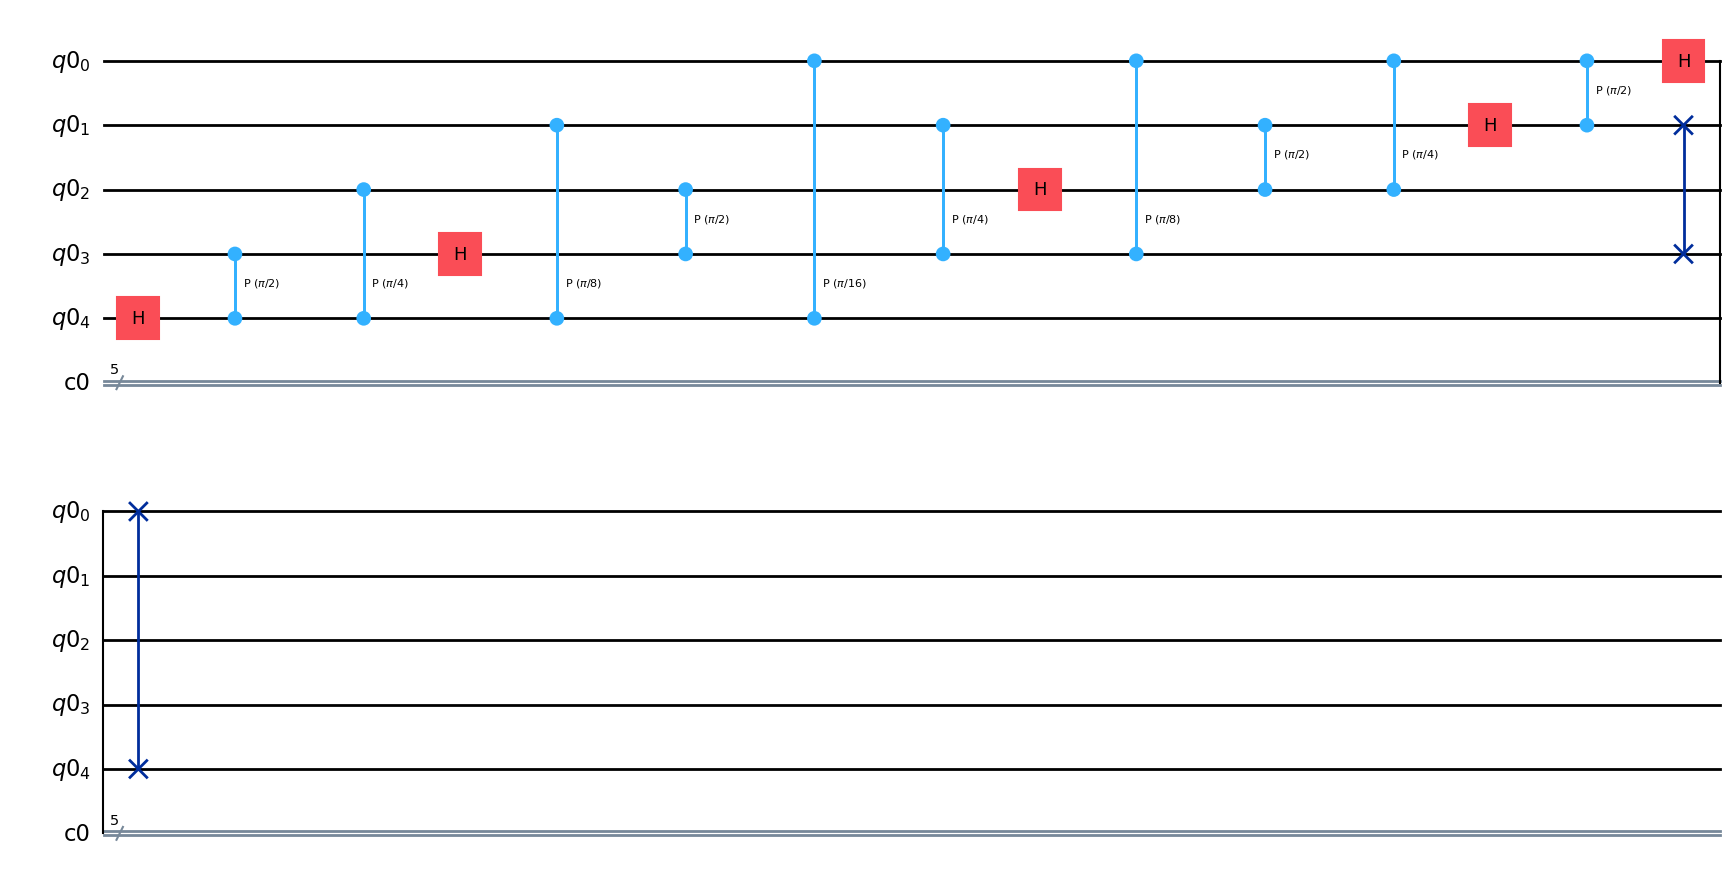

In [3]:
# Prepare for 5 qubits circuit - exercise 1

from qiskit import QuantumCircuit
from math import pi

def add_qft_5(qc):
    qc.h(4)
    qc.cp(pi / 2, 3, 4)
    qc.cp(pi / 4, 2, 4)
    qc.cp(pi / 8, 1, 4)
    qc.cp(pi / 16, 0, 4)

    qc.h(3)
    qc.cp(pi / 2, 2, 3)
    qc.cp(pi / 4, 1, 3)
    qc.cp(pi / 8, 0, 3)

    qc.h(2)
    qc.cp(pi / 2, 1, 2)
    qc.cp(pi / 4, 0, 2)

    qc.h(1)
    qc.cp(pi / 2, 0, 1)

    qc.h(0)

    qc.swap(0, 4)
    qc.swap(1, 3)

    return qc

qr = QuantumRegister(5)
cr = ClassicalRegister(5)
qc = QuantumCircuit(qr, cr)
qc_qft = add_qft_5(qc)
qc_qft.draw(output="mpl")



STATE |0>


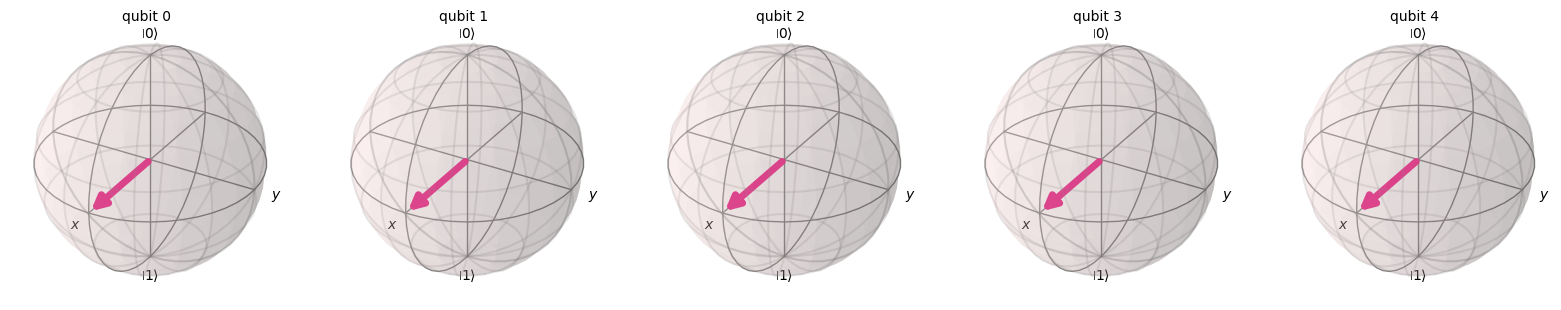

STATE |17>


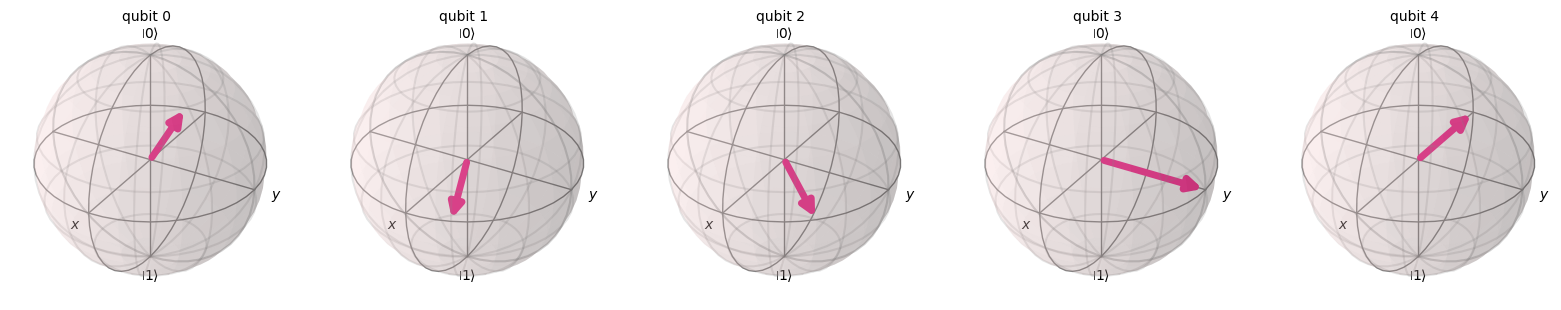

STATE |31>


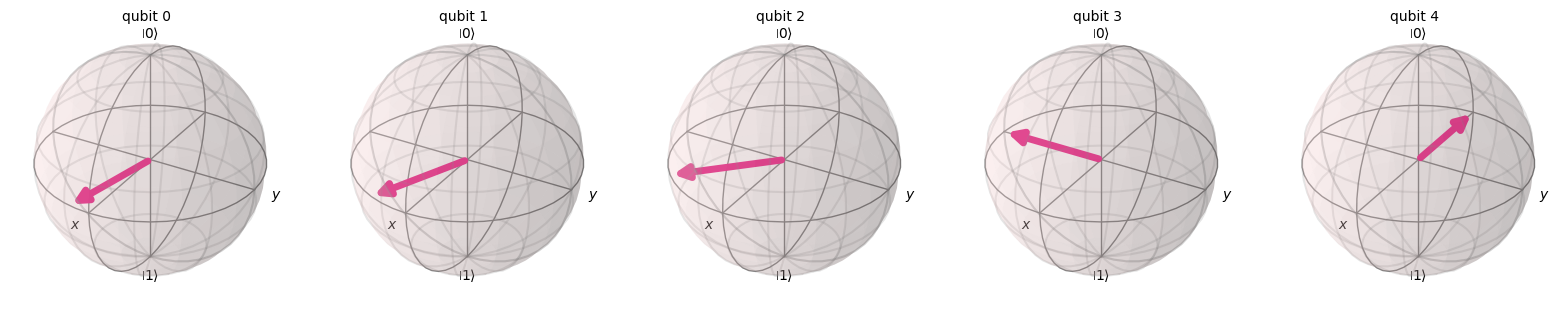

In [4]:
#now we simulate for |0>, |17>, and |31>

qc1 = QuantumCircuit(5) #|0>
qc2 = QuantumCircuit(5) #|17>
qc2.x(0)
qc2.x(4)
qc3 = QuantumCircuit(5) #|31>
qc3.x(0)
qc3.x(1)
qc3.x(2)
qc3.x(3)
qc3.x(4)

qc1.barrier()
qc2.barrier()
qc3.barrier()

qc1_qft = add_qft_5(qc1)
qc2_qft = add_qft_5(qc2)
qc3_qft = add_qft_5(qc3)

print("STATE |0>")
statevector1 = Statevector(qc1_qft)
display(plot_bloch_multivector(statevector1))

print("STATE |17>")
statevector2 = Statevector(qc2_qft)
display(plot_bloch_multivector(statevector2))

print("STATE |31>")
statevector3 = Statevector(qc3_qft)
display(plot_bloch_multivector(statevector3))



## Quantum Phase estimation

Task:
Implement quantum phase estimation algorithm (for ideal and noisy quantum simulator) for arbitrary searched phase $\theta$ following tutorial:

https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/quantum-phase-estimation

1. First consider phases for which $2^n \cdot \theta$ is an integer number (e.g. $\theta=1/8, \theta=3/8, \theta=5/8$), where n is the number of qubits in the counting register.

2. Next, consider phases for which $2^n \cdot \theta$ is not an integer (e.g. $\theta=1/3, \theta=1/5, \theta=1/7$). ***Show the acuurancy of estimating phase $\theta$ improves with increasing number of qubits  in the counting register.***

C:\Users\kacpe\AppData\Local\Temp\ipykernel_29436\2250909137.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qpe.append(QFT(3, inverse=True), [0, 1, 2])


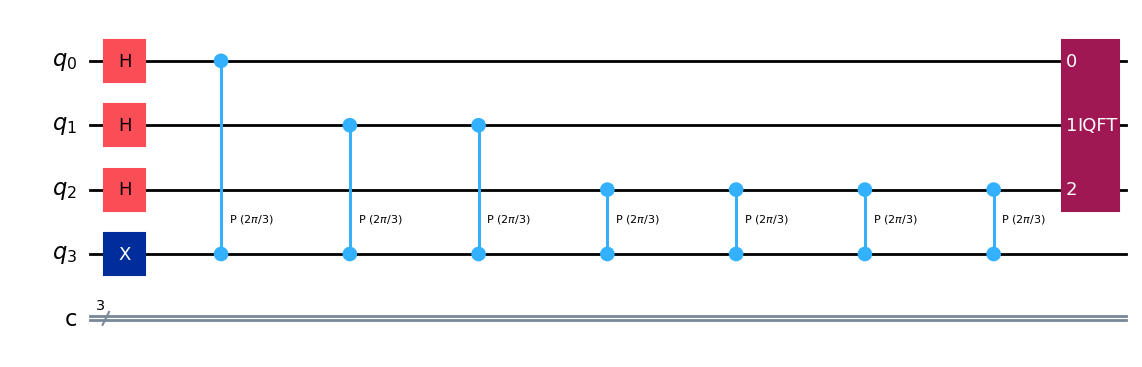

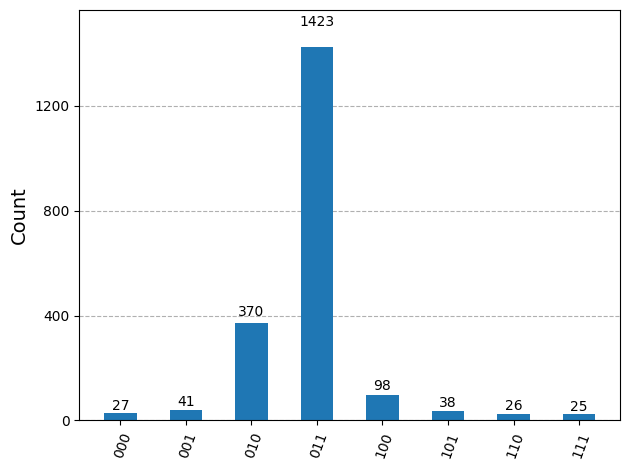

In [ ]:
#Here we have three counting qubits

qpe = QuantumCircuit(4, 3)
qpe.x(3)
qpe.draw(output="mpl")

for qubit in range(3):
    qpe.h(qubit)


repetitions = 1
for counting_qubit in range(3):
    for i in range(repetitions):
        qpe.cp(2*pi / 3, counting_qubit, 3)  # Here we can change theta 2*pi * theta
    repetitions *= 2


from qiskit.circuit.library import QFT

# Apply inverse QFT
qpe.append(QFT(3, inverse=True), [0, 1, 2])
display(qpe.draw(output="mpl"))


for n in range(3):
    qpe.measure(n, n)



aer_sim = AerSimulator()
shots = 2048

pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
t_qpe = pm.run(qpe)

sampler = Sampler(mode=aer_sim)
job = sampler.run([t_qpe], shots=shots)
result = job.result()
answer = result[0].data.c.get_counts()

#Based on plotted histogram and bit strucuture, we can evaluate theta
plot_histogram(answer)

C:\Users\kacpe\AppData\Local\Temp\ipykernel_29436\3757554940.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qpe.append(QFT(n_counting, inverse=True), range(n_counting))


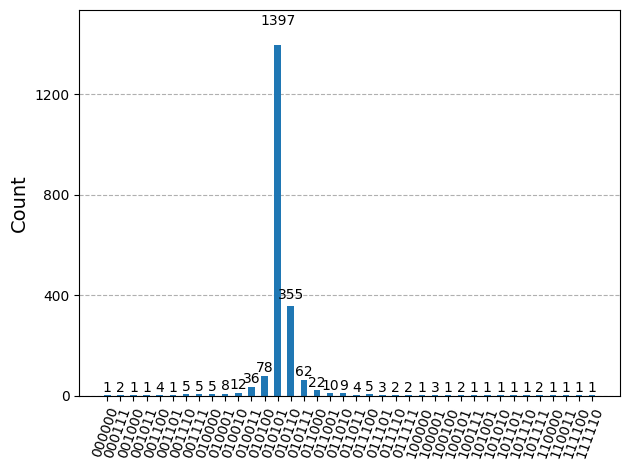

In [ ]:
#More counting qubits means better result

n_counting = 6 #number of counting qubits
theta = 1/3

target_qubit = n_counting

qpe = QuantumCircuit(n_counting + 1, n_counting)

qpe.x(target_qubit)

for qubit in range(n_counting):
    qpe.h(qubit)

repetitions = 1
for counting_qubit in range(n_counting):
    for _ in range(repetitions):
        qpe.cp(2 * pi * theta, counting_qubit, target_qubit)
    repetitions *= 2

qpe.append(QFT(n_counting, inverse=True), range(n_counting))

for qubit in range(n_counting):
    qpe.measure(qubit, qubit)

# display(qpe.draw(output="mpl"))

aer_sim = AerSimulator()
shots = 2048

pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
t_qpe = pm.run(qpe)

sampler = Sampler(mode=aer_sim)
job = sampler.run([t_qpe], shots=shots)
result = job.result()

answer = result[0].data.c.get_counts()

plot_histogram(answer)

## Shor Algorithm

### Implement Shor alghoritm (for ideal and noisy quantum simulator) for factoring number N=35, 
1. Find all the positive integers $a$ of the set $Z^*$; $a\in Z^*$, such that gcd(z, N) == 1.
2. Find periods of the all ellements of $Z^*$
3. For selected $a$ plot $a^x($mod $N)$ as a function of x, e.g. for a=9, N=55,
   <img src="attachment:967f0d90-7bd6-4191-828a-a42e2a56818d.png" width="700">
   
5. List in the table all a and r for given N, e.g. for N=55:
   <img src="attachment:04d6e859-cf13-4826-89e8-16d0dcc974a8.png" width="700">
6. Pick up few diffrerent values of $a$ for implementation of Shor alghoritm with QPHE approach
7. Try to impement Shor alghoritm for arbitrary N let's say N<100: N={4, 6, 9, 10, 14, 15, 21, 22, 25, 26, 33, 34, 35, 38, 39, 46, 49, 51, 57, 58, 62, 65, 69, 74, 77, 82, 85, 86, 87, 91, 93, 94, 95.}, This will require aplication of U gate which corresponds to permitations. You can define U operator using Operator class and its matrix representation. Than you have to add it to a quantum corcuit.


Hints in: https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/shor.ipynb 


In [4]:
#1
N = 35
candidates = range(1, N)

from math import gcd

Z_star = [a for a in candidates if gcd(a, N) == 1]
print(Z_star)

[1, 2, 3, 4, 6, 8, 9, 11, 12, 13, 16, 17, 18, 19, 22, 23, 24, 26, 27, 29, 31, 32, 33, 34]


In [13]:
#2
from math import gcd

N = 55
Z_star = [a for a in range(1, N) if gcd(a, N) == 1]

def order(a, N):
    r = 1
    val = a % N
    while val != 1:
        val = (val * a) % N
        r += 1
    return r

periods = {a: order(a, N) for a in Z_star}

for a, r in periods.items():
    print(f"a = {a}, period r = {r}")

a = 1, period r = 1
a = 2, period r = 20
a = 3, period r = 20
a = 4, period r = 10
a = 6, period r = 10
a = 7, period r = 20
a = 8, period r = 20
a = 9, period r = 10
a = 12, period r = 4
a = 13, period r = 20
a = 14, period r = 10
a = 16, period r = 5
a = 17, period r = 20
a = 18, period r = 20
a = 19, period r = 10
a = 21, period r = 2
a = 23, period r = 4
a = 24, period r = 10
a = 26, period r = 5
a = 27, period r = 20
a = 28, period r = 20
a = 29, period r = 10
a = 31, period r = 5
a = 32, period r = 4
a = 34, period r = 2
a = 36, period r = 5
a = 37, period r = 20
a = 38, period r = 20
a = 39, period r = 10
a = 41, period r = 10
a = 42, period r = 20
a = 43, period r = 4
a = 46, period r = 10
a = 47, period r = 20
a = 48, period r = 20
a = 49, period r = 10
a = 51, period r = 10
a = 52, period r = 20
a = 53, period r = 20
a = 54, period r = 2


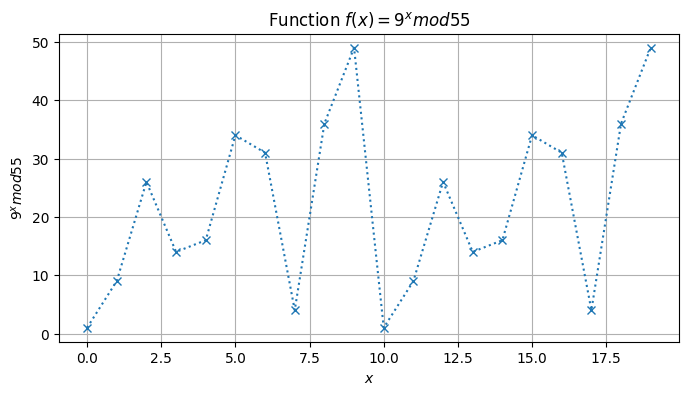

In [10]:
#3
import matplotlib.pyplot as plt

a = 9
N = 55
xvals = list(range(20))  # upewniamy się, że to zwykła lista liczb całkowitych
yvals = [(a ** x) % N for x in xvals]  # klasyczne potęgowanie z modulo

plt.figure(figsize=(8,4))
plt.plot(xvals, yvals, marker='x', linestyle='dotted')
plt.title(f'Function $f(x) = {a}^x mod {N}$')
plt.xlabel('$x$')
plt.ylabel(f'${a}^x mod {N}$')
plt.grid(True)
plt.show()

In [ ]:
#4 - already done in #2
#5 let's pick up a=13, N=35 for example

In [2]:
import numpy as np
from math import gcd, ceil, log2


#Function that creates U for given a and N
def modular_multiplication_matrix(a, N):
    if gcd(a, N) != 1:
        raise ValueError("a and N must be coprime")

    n = ceil(log2(N))
    dim = 2**n

    U = np.zeros((dim, dim), dtype=complex)

    for y in range(dim):
        if y < N:
            target = (a * y) % N
        else:
            target = y

        U[target, y] = 1

    return U


#QFT
def qft_dagger(n):
    """n-qubit QFTdagger the first n qubits in circ"""
    qc = QuantumCircuit(n)
    # Don't forget the Swaps!
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.h(j)
    qc.name = "QFT†"
    return qc




In [4]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate

N = 35
a = 13

n = ceil(log2(N))
N_COUNT = 2*n

qc = QuantumCircuit(N_COUNT + n, N_COUNT)

for q in range(N_COUNT):
    qc.h(q)

qc.x(N_COUNT)

for q in range(N_COUNT):
    power = 2**q
    U_matrix = modular_multiplication_matrix(pow(a, power, N), N)
    U_gate = UnitaryGate(U_matrix, label=f"{a}^{power} mod {N}")
    c_U_gate = U_gate.control()
    
    qc.append(
        c_U_gate,
        [q] + [i + N_COUNT for i in range(n)]
    )

qc.append(qft_dagger(N_COUNT), range(N_COUNT))

qc.measure(range(N_COUNT), range(N_COUNT))

qc.draw(fold=-1)

┌───┐                                                                                                                                                                                                               ┌────────┐┌─┐                                 
 q_0: ┤ H ├───────■───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤0       ├┤M├─────────────────────────────────
      ├───┤       │                                                                                                                                                                                                       │        │└╥┘┌─┐                              
 q_1: ┤ H ├───────┼───────────────■───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤1       ├─╫─┤M├──────────────────────────────
      ├───┤       │               │                                                                                                                                                                                       │        │ ║ └╥┘┌─┐                           
 q_2: ┤ H ├───────┼───────────────┼───────────────■───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤2       ├─╫──╫─┤M├───────────────────────────
      ├───┤       │               │               │                                                                                                                                                                       │        │ ║  ║ └╥┘┌─┐                        
 q_3: ┤ H ├───────┼───────────────┼───────────────┼───────────────■───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤3       ├─╫──╫──╫─┤M├────────────────────────
      ├───┤       │               │               │               │                                                                                                                                                       │        │ ║  ║  ║ └╥┘┌─┐                     
 q_4: ┤ H ├───────┼───────────────┼───────────────┼───────────────┼────────────────■──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤4       ├─╫──╫──╫──╫─┤M├─────────────────────
      ├───┤       │               │               │               │                │                                                                                                                                      │        │ ║  ║  ║  ║ └╥┘┌─┐                  
 q_5: ┤ H ├───────┼───────────────┼───────────────┼───────────────┼────────────────┼────────────────■─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤5       ├─╫──╫──╫──╫──╫─┤M├──────────────────
      ├───┤       │               │               │               │                │                │                                                                                                                     │   QFT† │ ║  ║  ║  ║  ║ └╥┘┌─┐               
 q_6: ┤ H ├───────┼───────────────┼───────────────┼───────────────┼────────────────┼────────────────┼────────────────■────────────────────────────────────────────────────────────────────────────────────────────────────┤6       ├─╫──╫──╫──╫──╫──╫─┤M├───────────────
      ├───┤       │               │               │               │                │                │                │                                                                                                    │        │ ║  ║  ║  ║  ║  ║ └╥┘┌─┐            
 q_7: ┤ H ├───────┼────────────

In [ ]:
# from qiskit import Aer, transpile
# from qiskit.visualization import plot_histogram

# aer_sim = Aer.get_backend('aer_simulator')
# t_qc = transpile(qc, aer_sim)
# counts = aer_sim.run(t_qc, shots=2048).result().get_counts()
# plot_histogram(counts)

ImportError: cannot import name 'Aer' from 'qiskit' (c:\Users\kacpe\OneDrive\Pulpit\Programming\qiskit_test\.venv\lib\site-packages\qiskit\__init__.py)